## Isolaction Forest Anomaly Detection 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
np.random.seed(42)

# Normal data
normal = np.random.normal(loc=[50, 5], scale=[10, 2], size=(300, 2))

# Anomalies (fraud)
fraud = np.random.uniform(low=[200, 15], high=[300, 25], size=(20, 2))

# Combine
X = np.vstack([normal, fraud])

# DataFrame
df = pd.DataFrame(X, columns=['Amount', 'Frequency'])

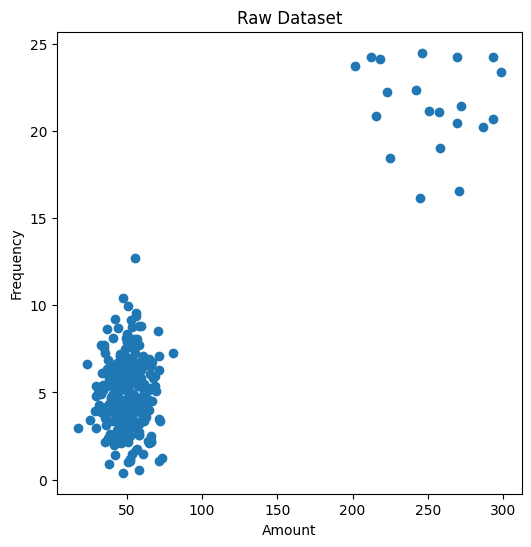

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(df['Amount'], df['Frequency'])
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Raw Dataset")
plt.show()

# Train Isolation Forest

In [46]:
from sklearn.ensemble import IsolationForest

In [47]:
X_feature = df[["Amount","Frequency"]]

In [49]:
model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)
model.fit(X_feature)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [51]:
# predict 
df["anomaly"] = model.predict(X_feature)

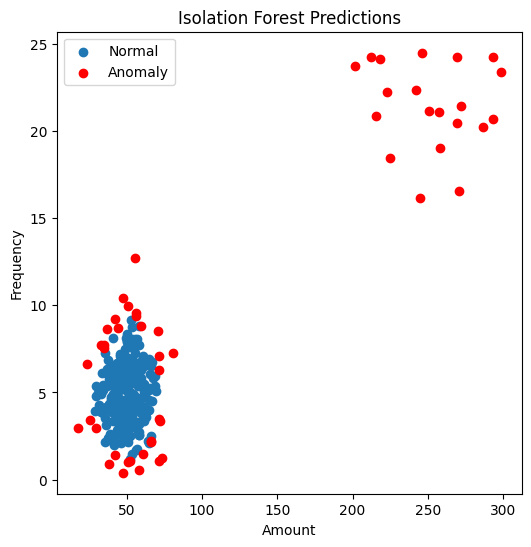

In [56]:
# Visualize Prediction

plt.figure(figsize=(6,6))

# Normal 
plt.scatter(
    df[df["anomaly"] == 1]["Amount"],
    df[df["anomaly"] == 1]["Frequency"],
    label="Normal"
)

# Anomaly
plt.scatter(
    df[df["anomaly"] == -1]["Amount"],
    df[df["anomaly"] == -1]["Frequency"],
   
    color = "red",
     label="Anomaly",
)

plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Isolation Forest Predictions")
plt.legend()
plt.show()

## Decision Boundary Visualization

In [ ]:
# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(df['Amount'].min()-20, df['Amount'].max()+20, 100),
    np.linspace(df['Frequency'].min()-5, df['Frequency'].max()+5, 100)
)


In [58]:

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

c:\Users\techn\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


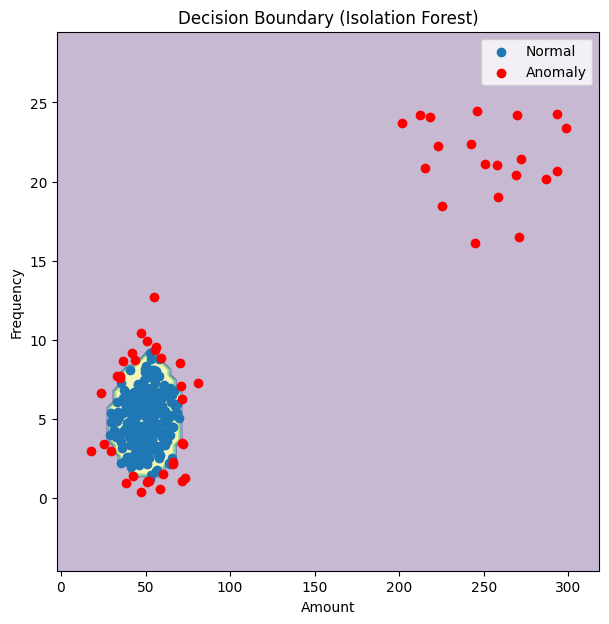

In [59]:
# Plot
plt.figure(figsize=(7,7))

# Background regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Normal points
plt.scatter(
    df[df['anomaly'] == 1]['Amount'],
    df[df['anomaly'] == 1]['Frequency'],
    label='Normal'
)

# Anomaly points
plt.scatter(
    df[df['anomaly'] == -1]['Amount'],
    df[df['anomaly'] == -1]['Frequency'],
    color='red',
    label='Anomaly'
)

plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Decision Boundary (Isolation Forest)")
plt.legend()
plt.show()

In [61]:
print(X_feature.shape)

(320, 2)
